| band_id| Band   | Usage                 | A Center| A Width | B Center| B_width | res|
| --:      | :--    | :--                 |--:      | --:     | --:     | --:     | --:|
| 1        | Band 1 | Coastal aerosol	  |  442.7	 |  21	   |  442.2  |	 21	   | 60 |
| 2        | Band 2 | Blue	              |  492.4	 |  66	   |  492.1  |	 66	   | 10 |
| 3        | Band 3 | Green	              |  559.8	 |  36	   |  559.0  |	 36	   | 10 |
| 4        | Band 4 | Red	              |  664.6	 |  31	   |  664.9  |	 31	   | 10 |
| 5        | Band 5 | Vegetation red edge |  704.1	 |  15	   |  703.8  |	 16	   | 20 |
| 6        | Band 6 | Vegetation red edge |  740.5	 |  15	   |  739.1  |	 15	   | 20 |
| 7        | Band 7 | Vegetation red edge |  782.8	 |  20	   |  779.7  |	 20	   | 20 |
| 8        | Band 8 | NIR	              |  832.8	 | 106     |  832.9  |	106	   | 10 |
| 9        | Band 8A| Narrow NIR          |  864.7	 |  21	   |  864.0  |	 22	   | 20 |
| 10       | Band 9 | Water vapour	      |  945.1	 |  20	   |  943.2  |	 21	   | 60 |
| 11       | Band 10| SWIR – Cirrus	      | 1373.5	 |  31	   | 1376.9  |	 30	   | 60 |
| 12       | Band 11| SWIR                | 1613.7	 |  91	   | 1610.4  |	 94	   | 20 |
| 13       | Band 12| SWIR                | 2202.4	 | 175     | 2185.7  |	185	   | 20 |

In [1]:
import xarray
import zarr
import pandas
import matplotlib.pyplot as plt
import geopandas
import numpy

In [2]:
from dask.distributed import LocalCluster
import dask.distributed
import logging

dask.config.set({'temporary-directory': '/data/dask'})
dask.config.set({'distributed.comm.timeouts.tcp': '1200s'})
dask.config.set({'distributed.comm.timeouts.connect': '1200s'})
dask.config.get('distributed.comm.timeouts')

cluster = dask.distributed.LocalCluster(n_workers=8,# Wed probably be better with less workers. Totally i/o bound
                                        threads_per_worker=2, 
                                        memory_limit='64GB', 
                                        processes=True, 
                                        dashboard_address='localhost:8787',
                                        silence_logs=logging.ERROR)

client = dask.distributed.Client(cluster) 

In [3]:
tiles = ['11SLB', # UCSB
         '10SFH', # LNBL 1
         '10SGH', # LNBL 2         
         '11SQD', # DRI 1
         '11SQC', # DRI 2
         '11TNK', # BSU 1
         '11TNJ', # BSU 2
         '11TPK', # BSU 3
         '11TPJ'  # BSU 5
        ]
tiles = ['UCSB', 'DRI', 'LBNL' , 'BSU']
tile = tiles[0]
tile

zarr_store = f'/scratch/tristate/{tile}_sharp.zarr'

In [4]:
zarr_store = '/scratch/sentinel2_arctic/fairbanks_sharp.zarr'

In [5]:
ds = xarray.open_zarr(zarr_store, consolidated=False)

# Todo
- [x] pansharpening
- [x] Add band coordinates as strings
- [x] slice to UCSB site
- [x] Calculate NDVI + NSDI
- [x] find the time with the lowest NDSI for each
- [x] Read masks: 
    - cloud
    - snow
    - shadow
- [x] R0 for summer only

# Subset

In [6]:
def normalize(data):
    data = data - numpy.nanmin(data)
    data = data / numpy.nanmax(data)     
    return data

def mask_nans(data):
    data = numpy.ma.masked_array(data, numpy.isnan(data))
    data[data.mask] = 0
    return data
    
def plot(da, time=None, mask=True):
    fig, ax = plt.subplots(dpi=300)    
        
    if time is not None:
        da = da.sel(time=time)

    rgb = da.squeeze()
                
    if 'band' in da.coords:
        rgb = rgb.transpose('y', 'x', 'band')
    else:
        rgb = rgb.transpose('y', 'x') 
    
    rgb = rgb.values

    if mask:
        rgb = mask_nans(rgb)
        
    img = ax.imshow(rgb)
    ax.axis('off')  
    ax.set_aspect('equal')
    cbar = fig.colorbar(img, ax=ax, shrink=0.7)    
    #return ax

In [7]:
# Only summer
ds = ds.sel(time=(ds['time.month'] >= 7) & (ds['time.month'] <= 9))

# Calc NDSI and NDVI
NDSI = (B3-B11)/(B3+B11)

In [8]:
%%time
reflectance = ds['reflectance']
# Make sure we don't have 0 in denominator; can happen due to negative reflectances

b8_b4 = (reflectance.sel(band='B8') + reflectance.sel(band='B4'))
b8_b4 = b8_b4.where(b8_b4!=0)
ndvi = (reflectance.sel(band='B8') - reflectance.sel(band='B4')) / b8_b4

b3_b11 = (reflectance.sel(band='B3') + reflectance.sel(band='B11'))
b3_b11 = b3_b11.where(b3_b11!=0)
ndsi = (reflectance.sel(band='B3') - reflectance.sel(band='B11')) / b3_b11

ndsi = ndsi.where(ndsi<1).where(ndsi>-1)
ndvi = ndvi.where(ndvi<1).where(ndvi>-1)

ds['ndvi'] = ndvi
ds['ndsi'] = ndsi

CPU times: user 295 ms, sys: 99.4 ms, total: 394 ms
Wall time: 387 ms


# Plot some date

CPU times: user 36.2 s, sys: 1min 5s, total: 1min 41s
Wall time: 1min 40s


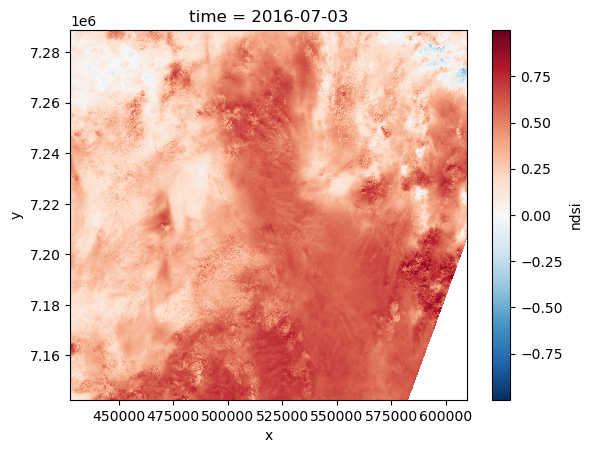

In [9]:
%%time
ds['ndsi'].isel(time=0).plot()

In [10]:
all_nans_mask = ds['ndsi'].isnull().all(dim='time')
all_nans_mask = all_nans_mask.compute()
all_nans_mask.where(all_nans_mask, drop=True)

<xarray.DataArray 'ndsi' (y: 0, x: 0)> Size: 0B
array([], shape=(0, 0), dtype=float64)
Coordinates:
  * y        (y) float64 0B 
  * x        (x) float64 0B 
Attributes: (12/84)
    AOT_QUANTIFICATION_VALUE:              1000.0
    AOT_QUANTIFICATION_VALUE_UNIT:         none
    AOT_RETRIEVAL_ACCURACY:                0.0
    AOT_RETRIEVAL_METHOD:                  CAMS
    BOA_QUANTIFICATION_VALUE:              10000
    BOA_QUANTIFICATION_VALUE_UNIT:         none
    ...                                    ...
    viewing_zenith_mean_B10:               2.77900768636106
    viewing_azimuth_mean_B10:              167.760731878817
    viewing_zenith_mean_B11:               2.95289863774776
    viewing_azimuth_mean_B11:              167.182153097404
    viewing_zenith_mean_B12:               3.14817413170569
    viewing_azimuth_mean_B12:              166.725237253648

In [11]:
# we can get nan NDSI so we fill them with 1 ... which should disqualify them from becoming R0
ds['ndsi'] = ds['ndsi'].fillna(1)

# R0 
#### For locations where there exists an observation with NDSI < 0:

1. From those locations, remove all locations which:
    - Have shadow
    - Have snowmask
2. Then, find the observation with the highest NDVI

#### For locations where there does not exist an observation with NDSI < 0:
1. Take observations whose blue reflectances is closest, but not smaller than 0.1

CPU times: user 1h 34min 25s, sys: 36min 51s, total: 2h 11min 17s
Wall time: 16h 34min 49s


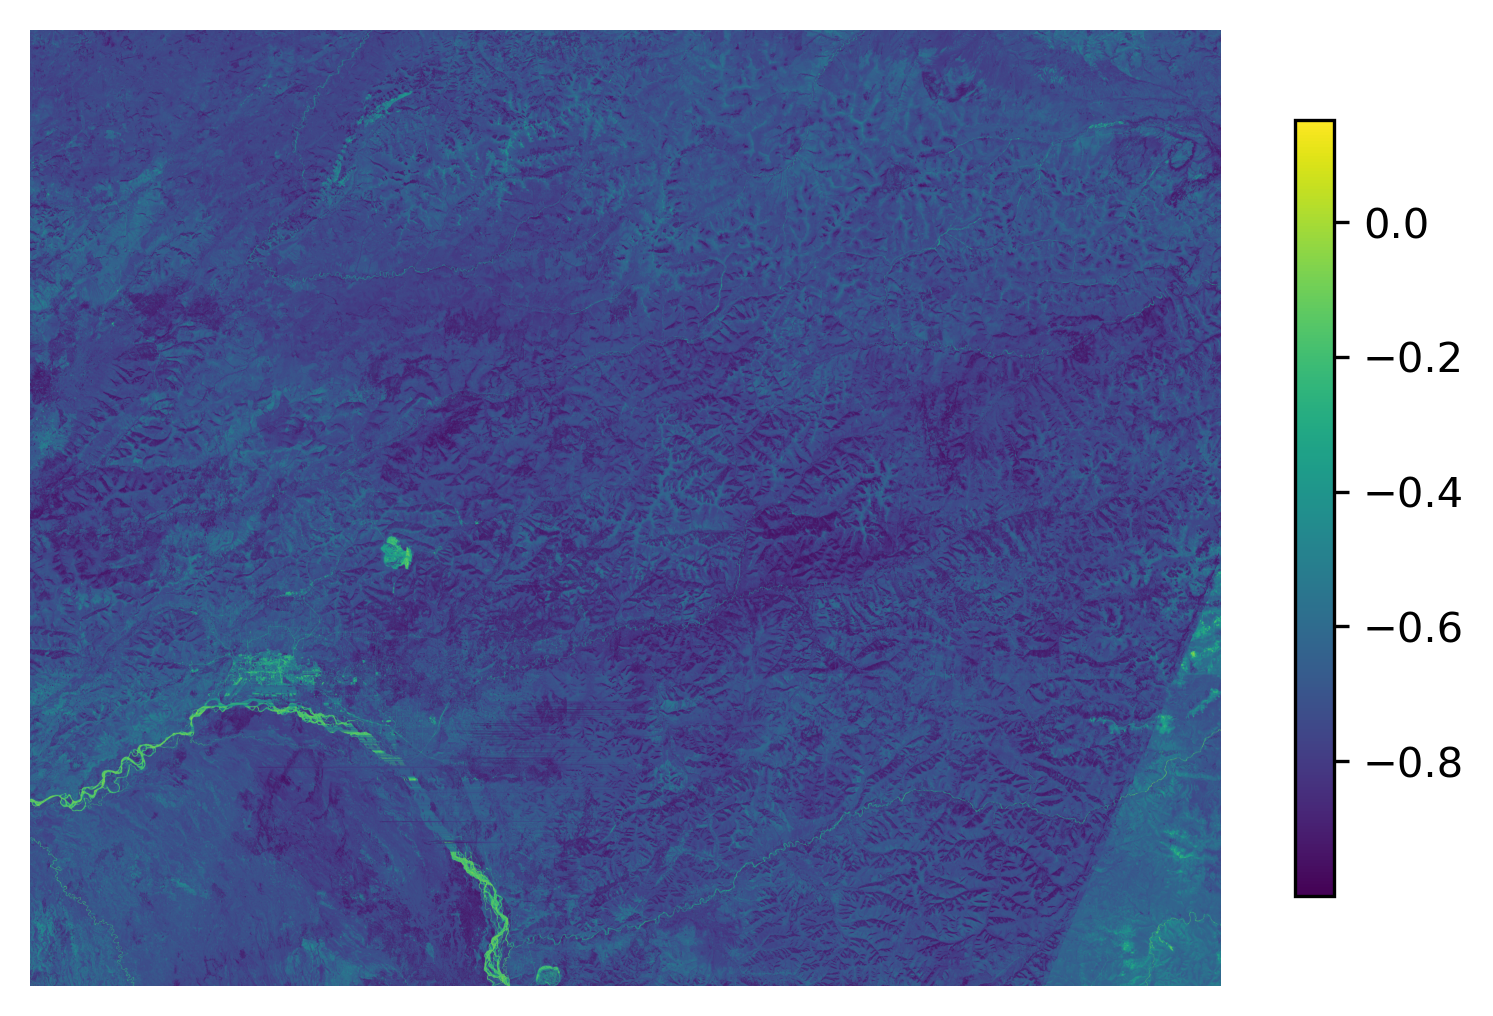

In [12]:
%%time
# this requires each chunk to be read
min_ndsi = ds['ndsi'].min(dim='time')
min_ndsi = min_ndsi.compute() # We can compute; this is only one timeslice and 1 band
plot(min_ndsi)

## SCL keys
| Value | meaning  |
| --:   | :--      |
| 0     | NO_DATA  |
| 1     | SATURATED_OR_DEFECTIVE|
| 2     | CAST_SHADOWS|
| 3     | CLOUD_SHADOWS|
| 4     | VEGETATION|
| 5     | NOT_VEGETATED|
| 6     | WATER|
| 7     | UNCLASSIFIED|
| 8     | CLOUD_MEDIUM_PROBABILITY|
| 9     | CLOUD_HIGH_PROBABILITY|
| 10    | THIN_CIRRUS|
| 11    | SNOW|

We are probably OK with 
- 4: VEGETATION
- 5: NOT_VEGETATED
- 6: WATER
- 7: UNCLASSIFIED

In [13]:
%%time
#candidates = ds.drop_vars(['sun_zenith_grid', 'sun_azimuth_grid', 'viewing_zenith_grid', 'viewing_azimuth_grid' ]).drop_dims(['x_angles', 'y_angles'])
candidates = ds.drop_vars(['sun_zenith_grid'])
#candidates = ds

# 1. Discard all **locations** that never have a NDSI below 0
ndsi_mask = min_ndsi < 0
candidates = candidates.where(ndsi_mask) 

# 2. Discard all observations when the cloud or snow probablility wasn't 0
candidates = candidates.where(candidates['CLD']==0)
candidates = candidates.where(candidates['SNW']==0)

# 3. Keep only observations that were veg, nonveg, or unclassified (the rest is cloud etc)
mask_scl = ((candidates['SCL']==4) | (candidates['SCL']==5)  | (candidates['SCL']==7))
candidates = candidates.where(mask_scl)

# 4. Keep only observations where MODIS band 3 (450 nm, +-blue, Sentinel band 2) is larger than 10%
#candidates = candidates.where(candidates['reflectance'].sel(band='B2') > 0.1)

# 5. Keep only observations with negative NDSI
candidates = candidates.where(candidates['ndsi']<0)

# 6. Keep only observations with more green than blue. There exists location where this isnt happening
candidates = candidates.where(candidates['reflectance'].sel(band='B2') < candidates['reflectance'].sel(band='B3'))

# 7. For all left observations, find for every location the observation with max NDVI
#candidates_max_ndvi = candidates['ndvi'].max(dim=('time'))

CPU times: user 13.2 s, sys: 1min 22s, total: 1min 35s
Wall time: 1min 23s


## Get R0 - via index

In [14]:
# Replace all nans in NDVI
masked_ndvi = candidates['ndvi'].fillna(-1)

In [ ]:
%%time
# Find the time indices whith the lowest NDVI
r0_idx = masked_ndvi.argmax(dim='time', skipna=True).compute()

/home/griessban/.conda/envs/spipy14/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 288.49 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [ ]:
%%time
# It seems like this is single-core and runs out of mem for lage regions
r0 = candidates.isel(time=r0_idx, drop=True)
#r0 = candidates[['reflectance']].isel(time=r0_idx, drop=True)

In [21]:
r0

<xarray.Dataset> Size: 20GB
Dimensions:      (y: 14628, x: 18208, band: 10)
Coordinates:
  * y            (y) float64 117kB 7.289e+06 7.289e+06 ... 7.142e+06 7.142e+06
  * x            (x) float64 146kB 4.277e+05 4.277e+05 ... 6.098e+05 6.098e+05
    time         (y, x) datetime64[ns] 2GB 2024-07-01 2024-07-01 ... 2016-08-17
  * band         (band) object 80B 'B2' 'B3' 'B4' 'B8' ... 'B5' 'B6' 'B7' 'B8A'
Data variables:
    spatial_ref  (y, x) float64 2GB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    SNW          (y, x) float32 1GB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    reflectance  (band, y, x) float32 11GB -0.0067 -0.006 ... 0.3903 0.2431
    CLD          (y, x) float32 1GB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    SCL          (y, x) float32 1GB 4.0 4.0 4.0 4.0 4.0 ... 4.0 4.0 4.0 4.0 4.0
    ndvi         (y, x) float32 1GB 0.9718 0.9721 0.9672 ... 0.7391 0.7305
    ndsi         (y, x) float32 1GB -0.8623 -0.8274 -0.7765 ... -0.5688 -0.4228
Attributes: (12/84)
    AOT_QUANTIFICATION_VALUE:              1000.0
    AOT_QUANTIFICATION_VALUE_UNIT:         none
    AOT_RETRIEVAL_ACCURACY:                0.0
    AOT_RETRIEVAL_METHOD:                  CAMS
    BOA_QUANTIFICATION_VALUE:              10000
    BOA_QUANTIFICATION_VALUE_UNIT:         none
    ...                                    ...
    viewing_zenith_mean_B10:               2.77900768636106
    viewing_azimuth_mean_B10:              167.760731878817
    viewing_zenith_mean_B11:               2.95289863774776
    viewing_azimuth_mean_B11:              167.182153097404
    viewing_zenith_mean_B12:               3.14817413170569
    viewing_azimuth_mean_B12:              166.725237253648

In [ ]:
r0 = r0.transpose('band', 'y', 'x')

In [ ]:
%%time
r0 = r0.compute()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.310747].


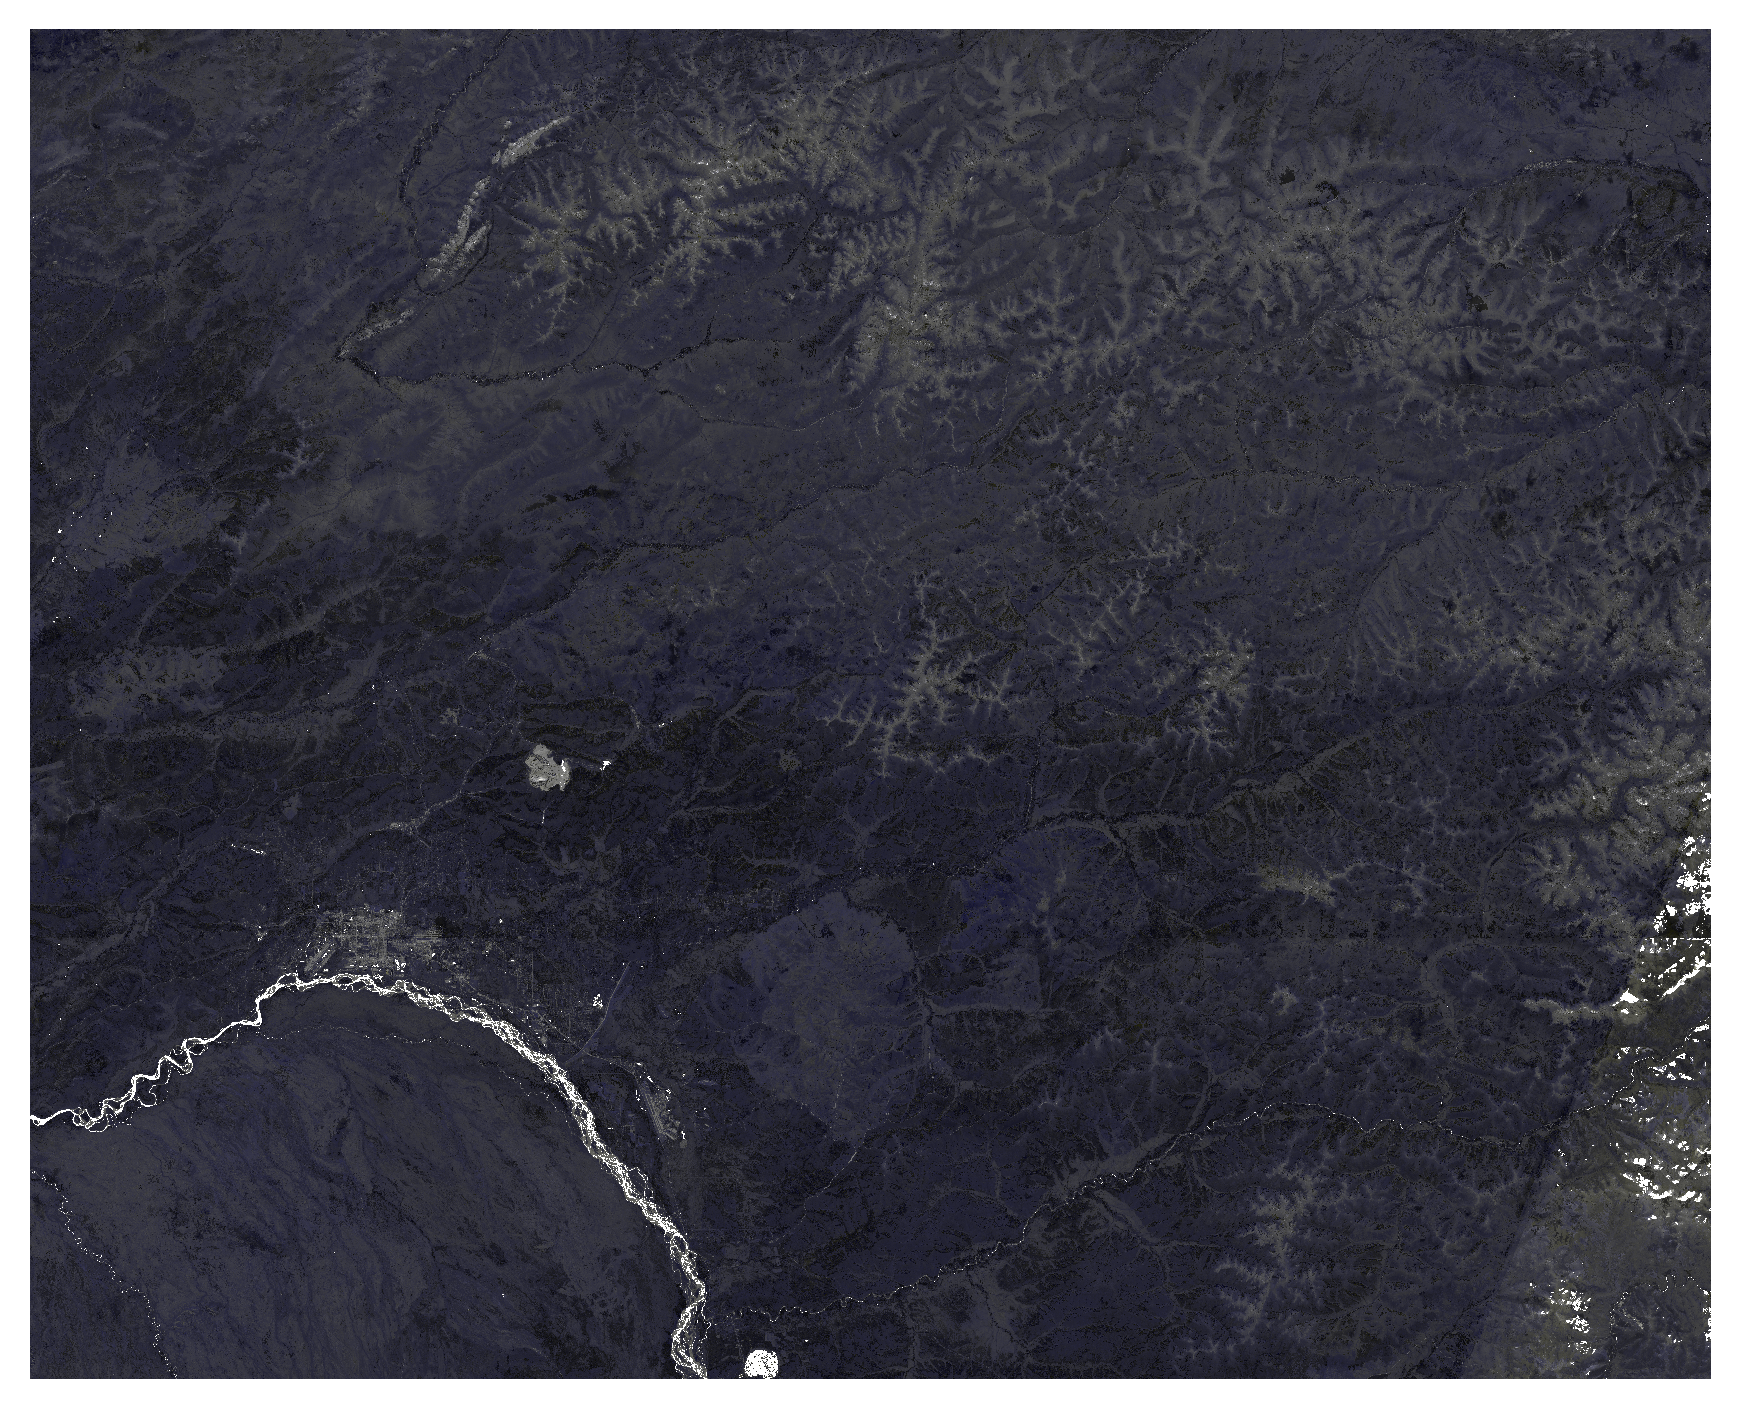

In [22]:
fig, ax = plt.subplots(dpi=300)

gamma = 2.2

(xarray.where(r0['reflectance']<-5, 0, r0['reflectance']).sel(band=['B4', 'B4', 'B3'])**(1/gamma)).plot.imshow(ax=ax)

ax.axis('off')  
ax.set_aspect('equal')
fig.tight_layout()

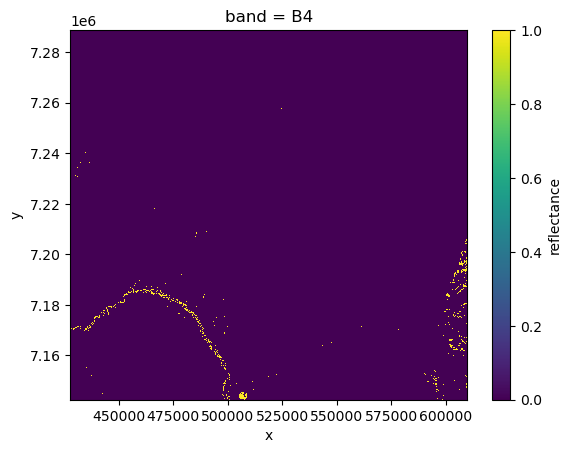

In [23]:
r0['reflectance'].sel(band='B4').isnull().plot()

In [25]:
import rioxarray
r0['spatial_ref'] = ds['spatial_ref']
r0.attrs["Conventions"] = "CF-1.8"
r0 = r0.rio.set_spatial_dims(x_dim="x",y_dim="y")
r0 = r0.rio.write_crs(ds['spatial_ref'].attrs['crs_wkt'])
r0 = r0.rio.write_transform()

In [28]:
coarsen = 10
c = r0['reflectance'].sel(band=['B4', 'B4', 'B3'])#.coarsen(x=coarsen, y=coarsen, boundary='trim').mean()
c = c.rio.write_transform()
c.name = 'rgb'
c.to_netcdf('r0_fairbanks.nc', format="NETCDF4", engine="netcdf4", encoding={'rgb': {"zlib": True, "complevel": 9}})

In [29]:
r0 = r0.chunk({'x': ds.chunks['x'], 'y': ds.chunks['y'], 'band': ds.chunks['band']})

In [31]:
%%time
nc_file = f'/data/sentinel2/zarrs_v3/{tile}_r0.nc'
r0.to_netcdf(nc_file)

/home/griessban/.conda/envs/spipy14/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 16.87 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 1min 1s, sys: 5min 16s, total: 6min 17s
Wall time: 8min 26s


In [32]:
%%time
zarr_store = f'/data/sentinel2/zarrs_v3/{tile}_r0.zarr'
r0.to_zarr(zarr_store, mode='w', consolidated=False, zarr_format=3)

/home/griessban/.conda/envs/spipy14/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 16.87 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 33.1 s, sys: 9min 44s, total: 10min 17s
Wall time: 11min 2s


# Some plots

In [ ]:
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(dpi=300)

categories = ['Veg', 'Nonveg', 'Water', 'unclass']
colors = ['blue', 'green', 'red', 'purple']  # Example colors, you can adjust as needed
cmap = ListedColormap(colors)

img = ax.imshow(r0['SCL'].astype(int), cmap=cmap, vmin=4, vmax=7, alpha=1)

cbar = fig.colorbar(img, ax=ax, shrink=0.7)    
cbar.ax.set_yticks([4,5,6,7])
cbar.ax.set_yticklabels(categories)

ax.axis('off')  
ax.set_aspect('equal')

In [ ]:
client.close()
cluster.close()

# To geotiff

In [ ]:
r0.rio.write_crs(32611, inplace=True)
r0.rio.set_spatial_dims('x', 'y', inplace=True)
tiff = r0['reflectance'].to_dataset('band')

#tiff[['ndsi', 'ndvi']] = r0[['ndsi', 'ndvi']]
tiff = tiff.fillna(-1)
tiff.rio.to_raster('r0.tiff')

In [ ]:
1

In [ ]:
1